# Market Field Calculus v1: preliminary reproducible evaluation

## tl;dr

This notebook reruns the engineering and descriptive-empirical audit from a frozen public-data snapshot. The tested field passed **46/46** causal prefix checks and **16/16** fixed-input determinism checks. Horizon-grid step 4 nevertheless produced median IQR-normalized MAE **0.203** and p95 **0.428**, so grid density is a model parameter. Daily retrospective dictionaries selected only **1–2** states and supplied just **2** reliable next-state entries across seven assets. These are implementation and calibration diagnostics—not evidence of forecast skill or trading performance.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

HERE = Path.cwd()
run = subprocess.run(
    [sys.executable, "evaluate_market_field.py"],
    cwd=HERE,
    check=True,
    capture_output=True,
    text=True,
)
summary = json.loads((HERE / "results" / "summary.json").read_text(encoding="utf-8"))
print(f"Executed with Python {sys.version.split()[0]}")
print(f"Recomputed {summary['dataset_count']} datasets / {summary['completed_bar_count']:,} completed bars in {summary['runtime_seconds']:.1f}s")

Executed with Python 3.13.14
Recomputed 15 datasets / 9,235 completed bars in 23.5s


## Context & Methods

The audit asks whether the current implementation is causally computable, repeatable, numerically stable to horizon-grid resolution, well-defined across all supported timeframes, and honest about the retrospective state layer. It also tests the options wrapper's completed-bar and shadow-only boundaries.

The causal check compares full-history outputs with outputs recomputed from 60%, 80%, and 95% prefixes for all live channels, derivatives, strata, carriers, and carrier ratios. A separate stress test mutates the full future suffix after a SPY-daily cutoff. The resolution check treats horizons 8–64 at step 1 as a numerical reference and compares steps 2, 4, and 8 after a 128-bar warm-up. Lexicons use chronological fit, calibration, and evaluation partitions.

### Key Assumptions

- The frozen Yahoo snapshot is adequate for engineering diagnostics but is not exchange-grade data.
- A bar is eligible only under the completion rules recorded in the manifest.
- Exact-zero audit results mean equality at serialized implementation precision, not a theorem over all possible input series.
- Highly autocorrelated bars and overlapping outcomes are not independent samples.
- The learned lexicon is retrospective and excluded from the options field overlay.
- No P&L, forecast target, transaction cost, or statistical discovery hypothesis is evaluated here.

## Data

In [2]:
manifest = json.loads((HERE / "data" / "raw" / "manifest.json").read_text(encoding="utf-8"))
profile = pd.read_csv(HERE / "results" / "dataset_profile.csv")
quality = pd.DataFrame([summary["data_quality"]])
display(quality)
display(profile[["dataset_id", "symbol", "timeframe", "rows", "coverage_start", "coverage_end"]])
print("Snapshot:", manifest["observed_at_utc"])
print("Provider:", manifest["provider"], "/", manifest["provider_package"])

,all_monotonic,duplicate_timestamps,incomplete_rows_excluded,invalid_ohlcv_rows,missing_ohlcv_cells
0,True,0,15,0,0


,dataset_id,symbol,timeframe,rows,coverage_start,coverage_end
0,btc_usd_1d,BTC-USD,1D,749,2024-07-03T00:00:00+00:00,2026-07-21T00:00:00+00:00
1,gld_1d,GLD,1D,749,2023-07-26T04:00:00+00:00,2026-07-21T04:00:00+00:00
2,iwm_1d,IWM,1D,749,2023-07-26T04:00:00+00:00,2026-07-21T04:00:00+00:00
3,qqq_1d,QQQ,1D,749,2023-07-26T04:00:00+00:00,2026-07-21T04:00:00+00:00
4,spy_15m,SPY,15m,499,2026-06-24T14:30:00+00:00,2026-07-22T15:30:00+00:00
5,spy_1d,SPY,1D,749,2023-07-26T04:00:00+00:00,2026-07-21T04:00:00+00:00
6,spy_1w,SPY,1W,499,2016-12-26T05:00:00+00:00,2026-07-13T04:00:00+00:00
7,spy_1h,SPY,1h,499,2026-04-09T13:30:00+00:00,2026-07-22T14:30:00+00:00
8,spy_1m,SPY,1m,499,2026-07-21T13:59:00+00:00,2026-07-22T15:47:00+00:00
9,spy_2h,SPY,2h,499,2026-01-20T16:30:00+00:00,2026-07-22T13:30:00+00:00


Snapshot: 2026-07-22T15:48:24.325098+00:00
Provider: Yahoo Finance via yfinance YahooProvider / yfinance 1.1.0


## Results

,diagnostic,checks,max_abs_error,passes,tolerance,max_unique_hashes
0,prefix invariance,46,0.0,46,0.0001,NaN
1,determinism,16,NaN,16,NaN,1.0


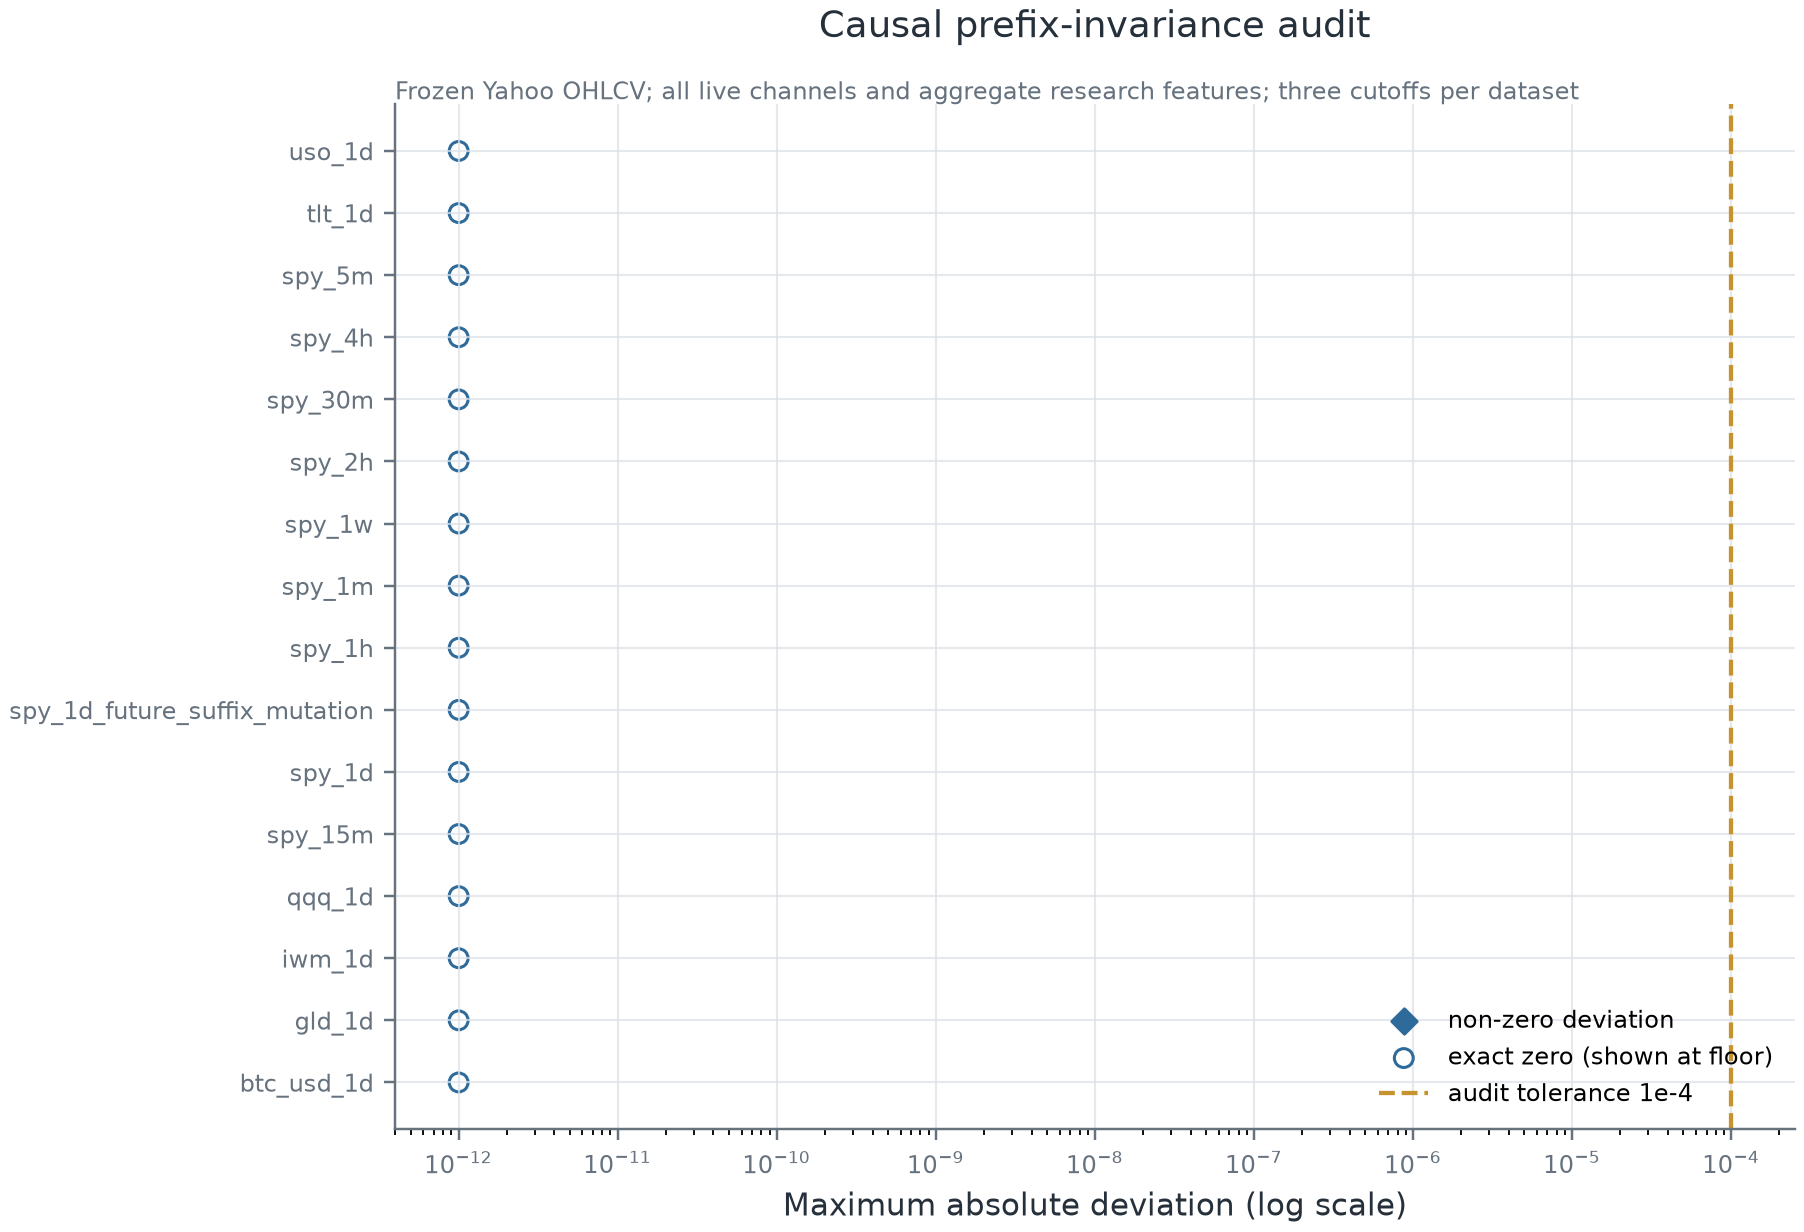

In [3]:
audit = pd.DataFrame([
    {"diagnostic": "prefix invariance", **summary["prefix_invariance"]},
    {"diagnostic": "determinism", **summary["determinism"]},
])
display(audit)
display(Image(filename=str(HERE / "figures" / "fig_causal_prefix_audit.png")))

,dataset_id,feature,iqr_normalized_mae,correlation,final_abs_error
131,spy_15m,scaling_exponent,0.730467,0.910891,0.2589
179,spy_30m,scaling_exponent,0.669802,0.914467,0.1495
227,spy_1h,scaling_exponent,0.569816,0.952888,0.0829
275,spy_2h,scaling_exponent,0.487660,0.911708,0.0602
415,spy_1w,geometry,0.480397,0.841112,0.0163
178,spy_30m,cascade_bias,0.465617,0.817249,0.0380
658,uso_1d,cascade_bias,0.461610,0.821776,0.0549
33,spy_1m,propagation,0.447577,0.905518,0.0188
562,tlt_1d,cascade_bias,0.440544,0.829264,0.0437
271,spy_2h,geometry,0.427717,0.768254,0.0091


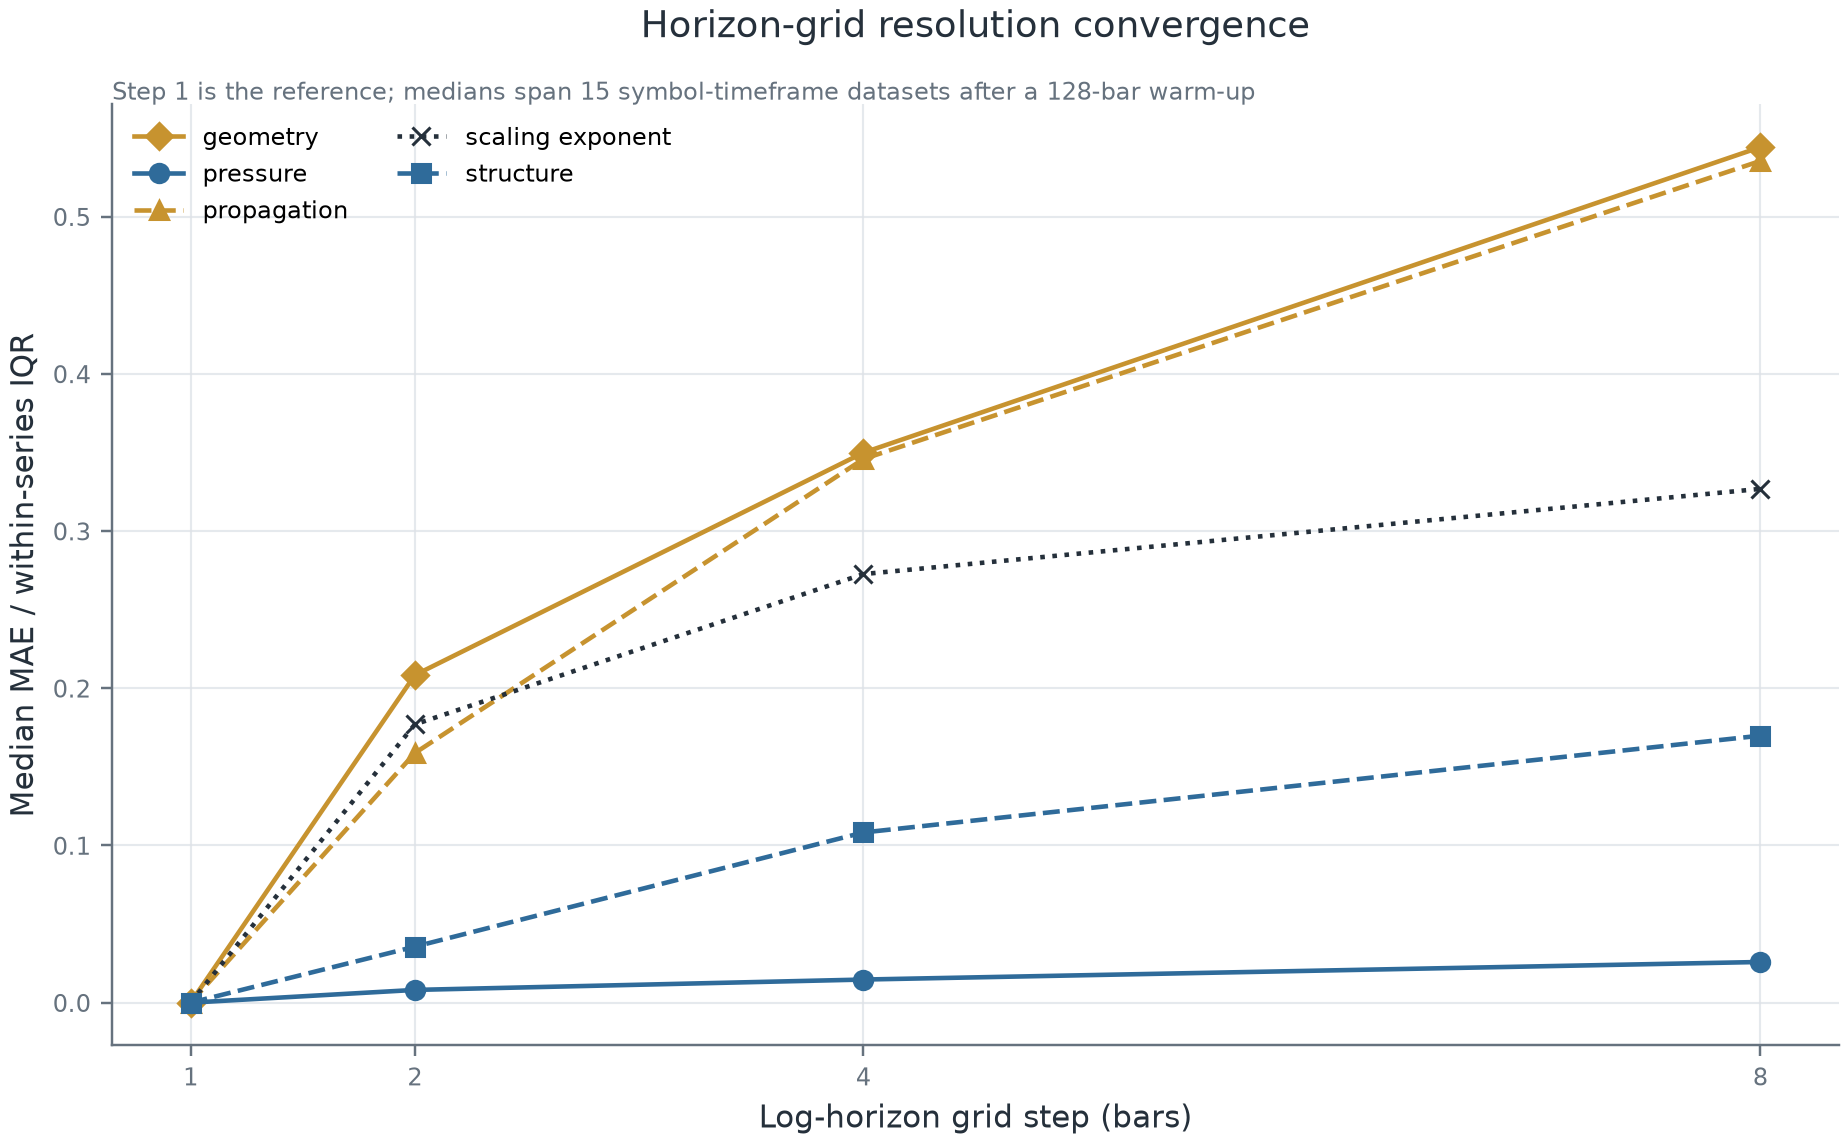

In [4]:
resolution = pd.read_csv(HERE / "results" / "resolution_convergence.csv")
step4 = resolution[resolution["horizon_step"] == 4].sort_values("iqr_normalized_mae", ascending=False)
display(step4[["dataset_id", "feature", "iqr_normalized_mae", "correlation", "final_abs_error"]].head(12))
display(Image(filename=str(HERE / "figures" / "fig_resolution_convergence.png")))

,timeframe,bars,evaluation_bars,coverage_days,finite_feature_share,pressure_median,pressure_iqr,pressure_lag1_autocorrelation,median_abs_pressure_change,median_abs_velocity,structure_median,geometry_median,information_median,phase_transitions_per_100_bars,median_phase_run_bars,median_phase_run_nominal_minutes,positive_phase_share,neutral_phase_share,negative_phase_share
0,1m,499,403,1.075000,1.0,0.0141,0.12945,0.996272,0.00555,0.3768,0.4483,0.3757,0.4285,3.980100,12.0,12.0,0.451613,0.267990,0.280397
1,5m,499,403,8.833333,1.0,-0.0061,0.09950,0.995882,0.00560,0.3819,0.4403,0.3761,0.4491,5.472637,9.0,45.0,0.312655,0.258065,0.429280
2,15m,499,403,28.041667,1.0,0.0189,0.16525,0.995715,0.00770,0.4060,0.4669,0.3786,0.4263,4.975124,15.0,225.0,0.493797,0.178660,0.327543
3,30m,499,403,56.812500,1.0,-0.0001,0.14655,0.996453,0.00635,0.3763,0.4648,0.3808,0.4417,5.472637,9.0,270.0,0.374690,0.166253,0.459057
4,1h,499,403,104.041667,1.0,0.0460,0.16260,0.996061,0.00700,0.3806,0.4718,0.3811,0.4525,4.726368,8.5,510.0,0.637717,0.116625,0.245658
5,2h,499,403,182.875000,1.0,0.0350,0.21965,0.997580,0.00760,0.3782,0.4659,0.3840,0.4628,2.985075,12.0,1440.0,0.558313,0.146402,0.295285
6,4h,499,403,365.000000,1.0,0.0247,0.11945,0.996965,0.00490,0.3554,0.4362,0.3744,0.4887,5.721393,10.5,2520.0,0.535980,0.305211,0.158809
7,1D,749,653,1091.000000,1.0,0.1111,0.18560,0.996514,0.00690,0.3637,0.4954,0.3845,0.4529,3.987730,8.0,3120.0,0.747320,0.142420,0.110260
8,1W,499,403,3485.958333,1.0,0.1180,0.20890,0.995363,0.00670,0.3735,0.4935,0.3806,0.4394,2.985075,15.0,29250.0,0.761787,0.138958,0.099256


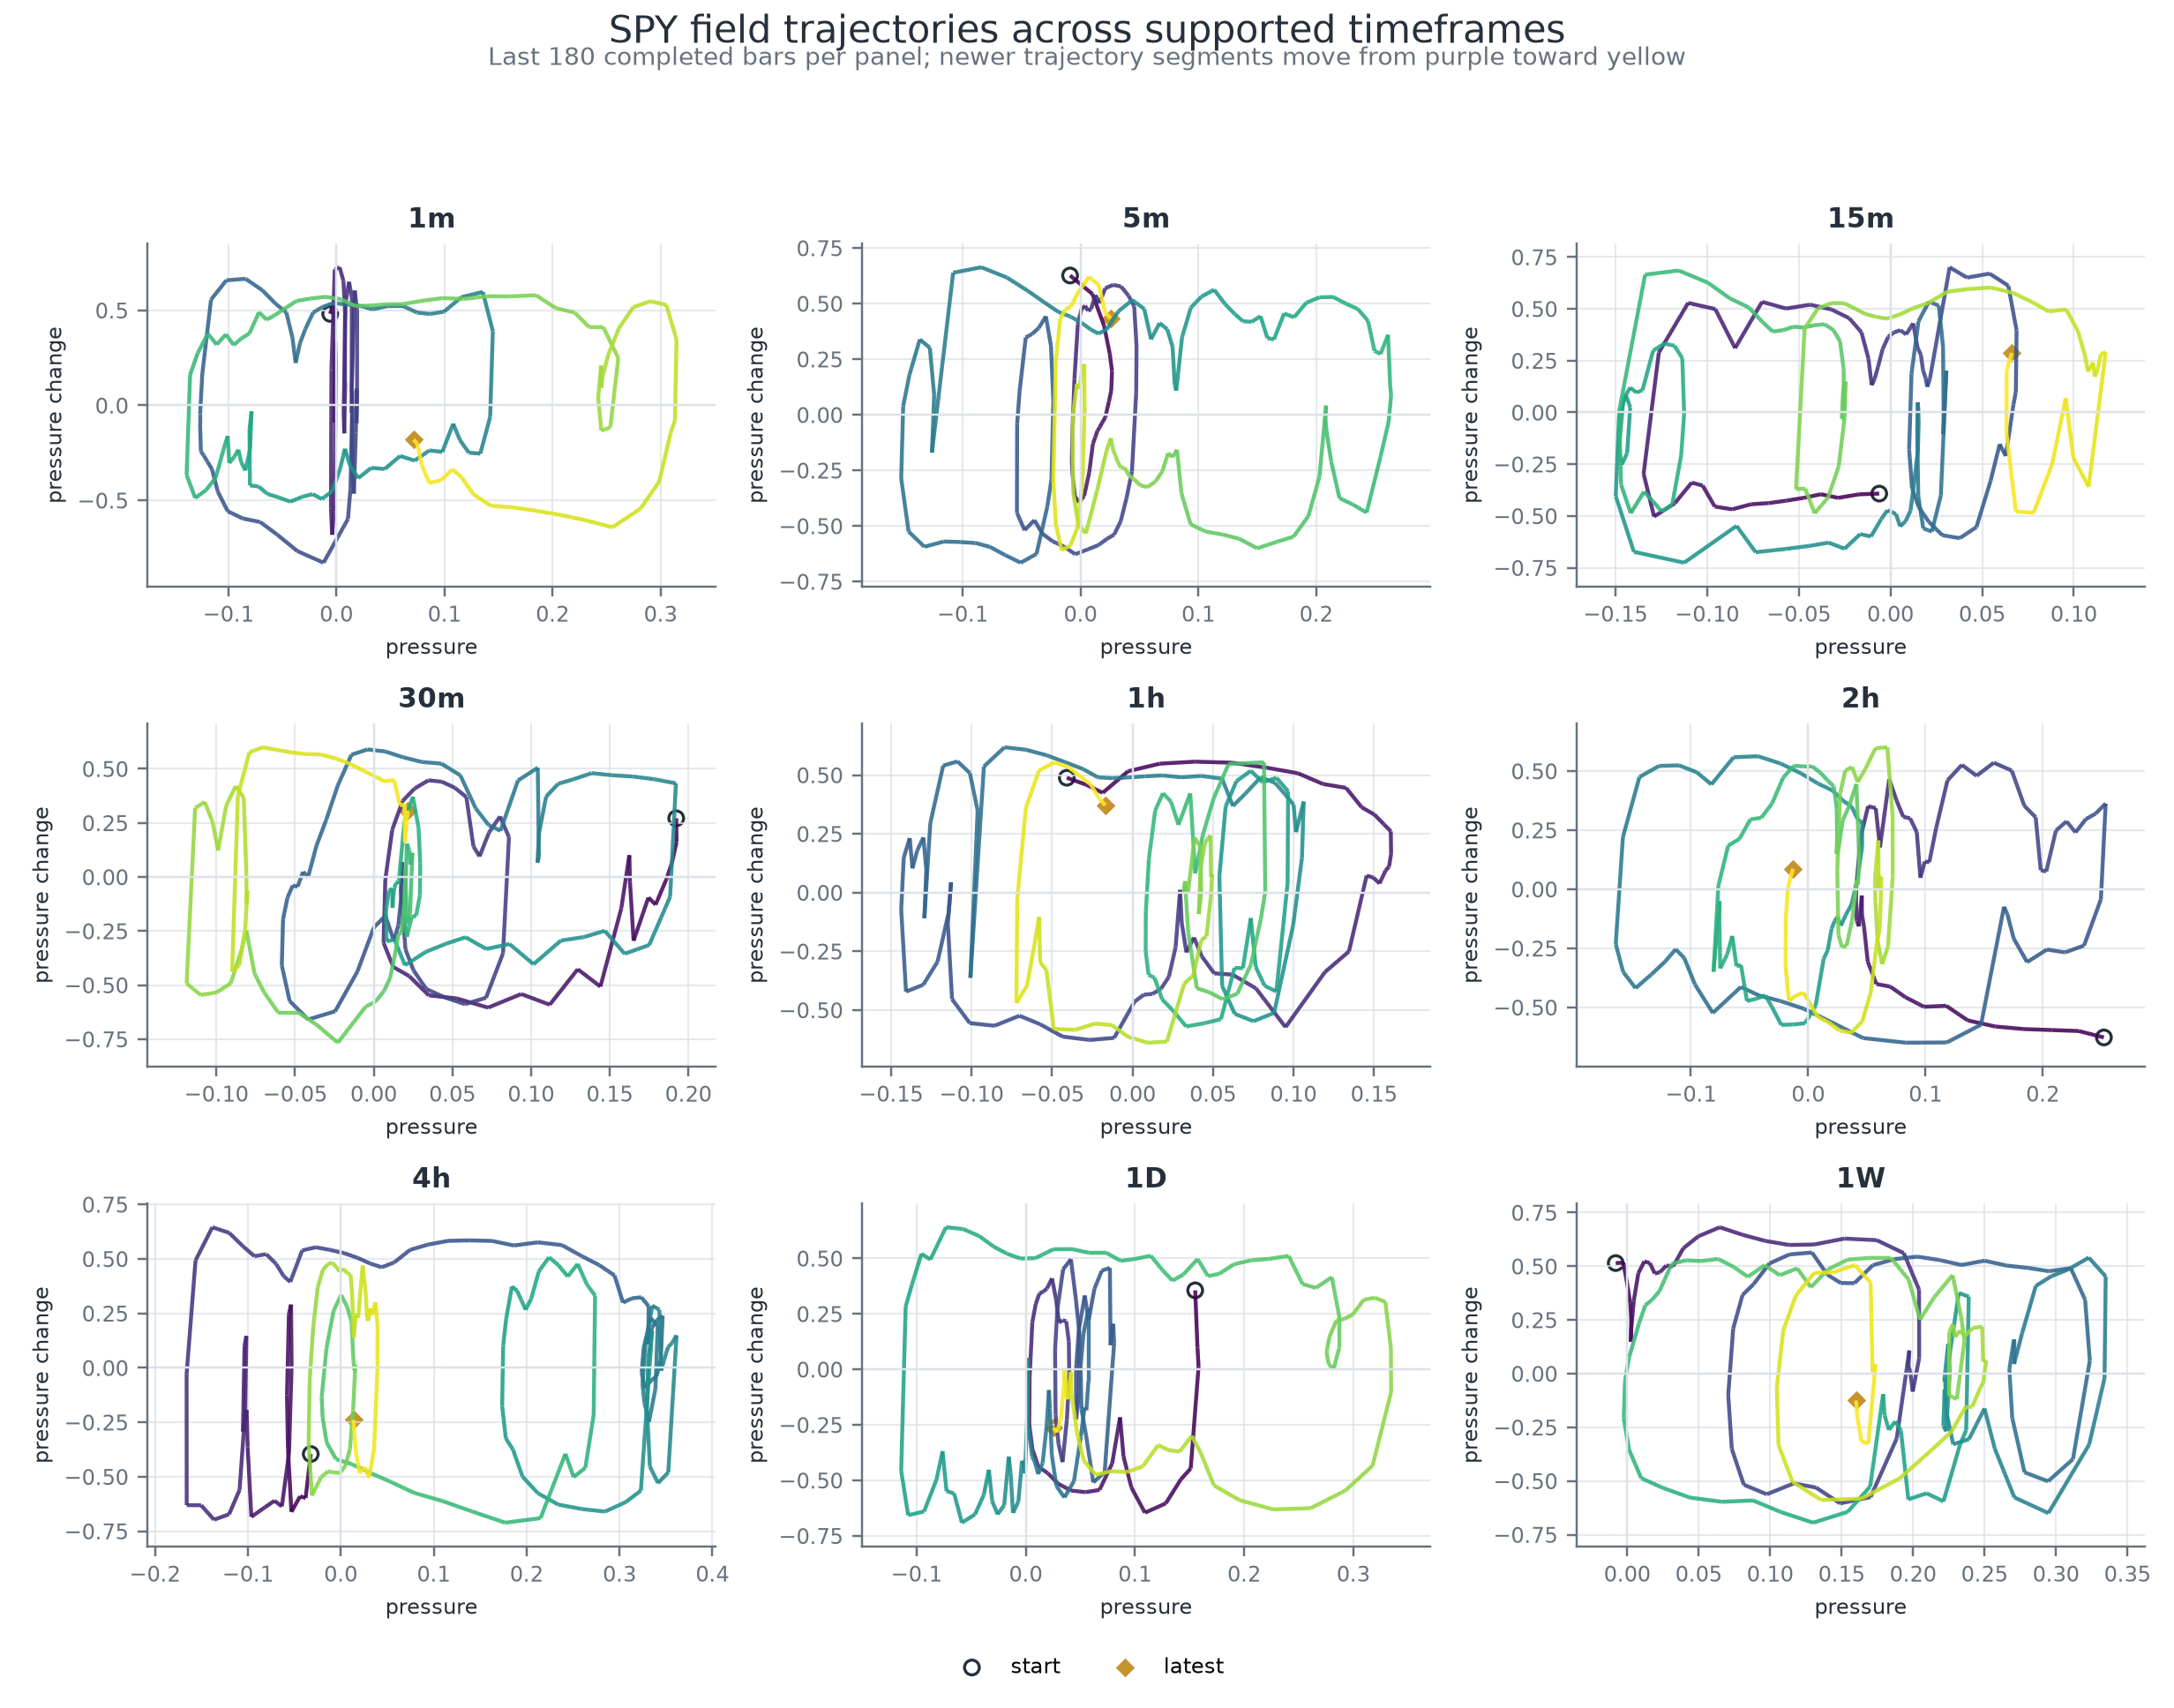

In [5]:
timeframes = pd.read_csv(HERE / "results" / "timeframe_behavior.csv")
display(timeframes)
display(Image(filename=str(HERE / "figures" / "fig_timeframe_phase_portraits.png")))

,dataset_id,archetype_count,fit_mean_silhouette,fit_bars,calibration_bars,evaluation_bars,distance_tail_coverage,outside_range_rate_when_scored,evaluation_state_changes,evaluation_median_run_bars,fit_transition_count,reliable_next_state_count,current_state,current_distance_tail_score,current_distance_tail_support
0,spy_1d,2,0.278031,236,117,300,1.000000,0.366667,11,11.5,6,0,F.002,0.509434,52
1,qqq_1d,2,0.251756,236,117,300,1.000000,0.426667,12,9.0,12,2,F.001,0.512821,77
2,iwm_1d,2,0.426800,236,117,300,0.753333,0.000000,10,23.0,4,0,F.001,0.991525,117
3,tlt_1d,2,0.258655,236,117,300,1.000000,0.013333,11,2.5,2,0,F.001,0.904762,62
4,gld_1d,1,0.000000,236,117,300,1.000000,0.053333,0,300.0,0,0,F.001,0.457627,117
5,uso_1d,1,0.000000,236,117,300,1.000000,0.160000,0,300.0,0,0,F.001,0.601695,117
6,btc_usd_1d,2,0.255779,236,117,300,0.323333,0.113402,19,4.0,2,0,F.001,NaN,0


,prefix_fraction,prefix_bars,overlap_bars,full_archetypes,prefix_archetypes,adjusted_rand_index,interpretation
0,0.70,524,75,2,1,0.000000,Window-native dictionary stability diagnostic;...
1,0.85,637,188,2,2,0.872967,Window-native dictionary stability diagnostic;...


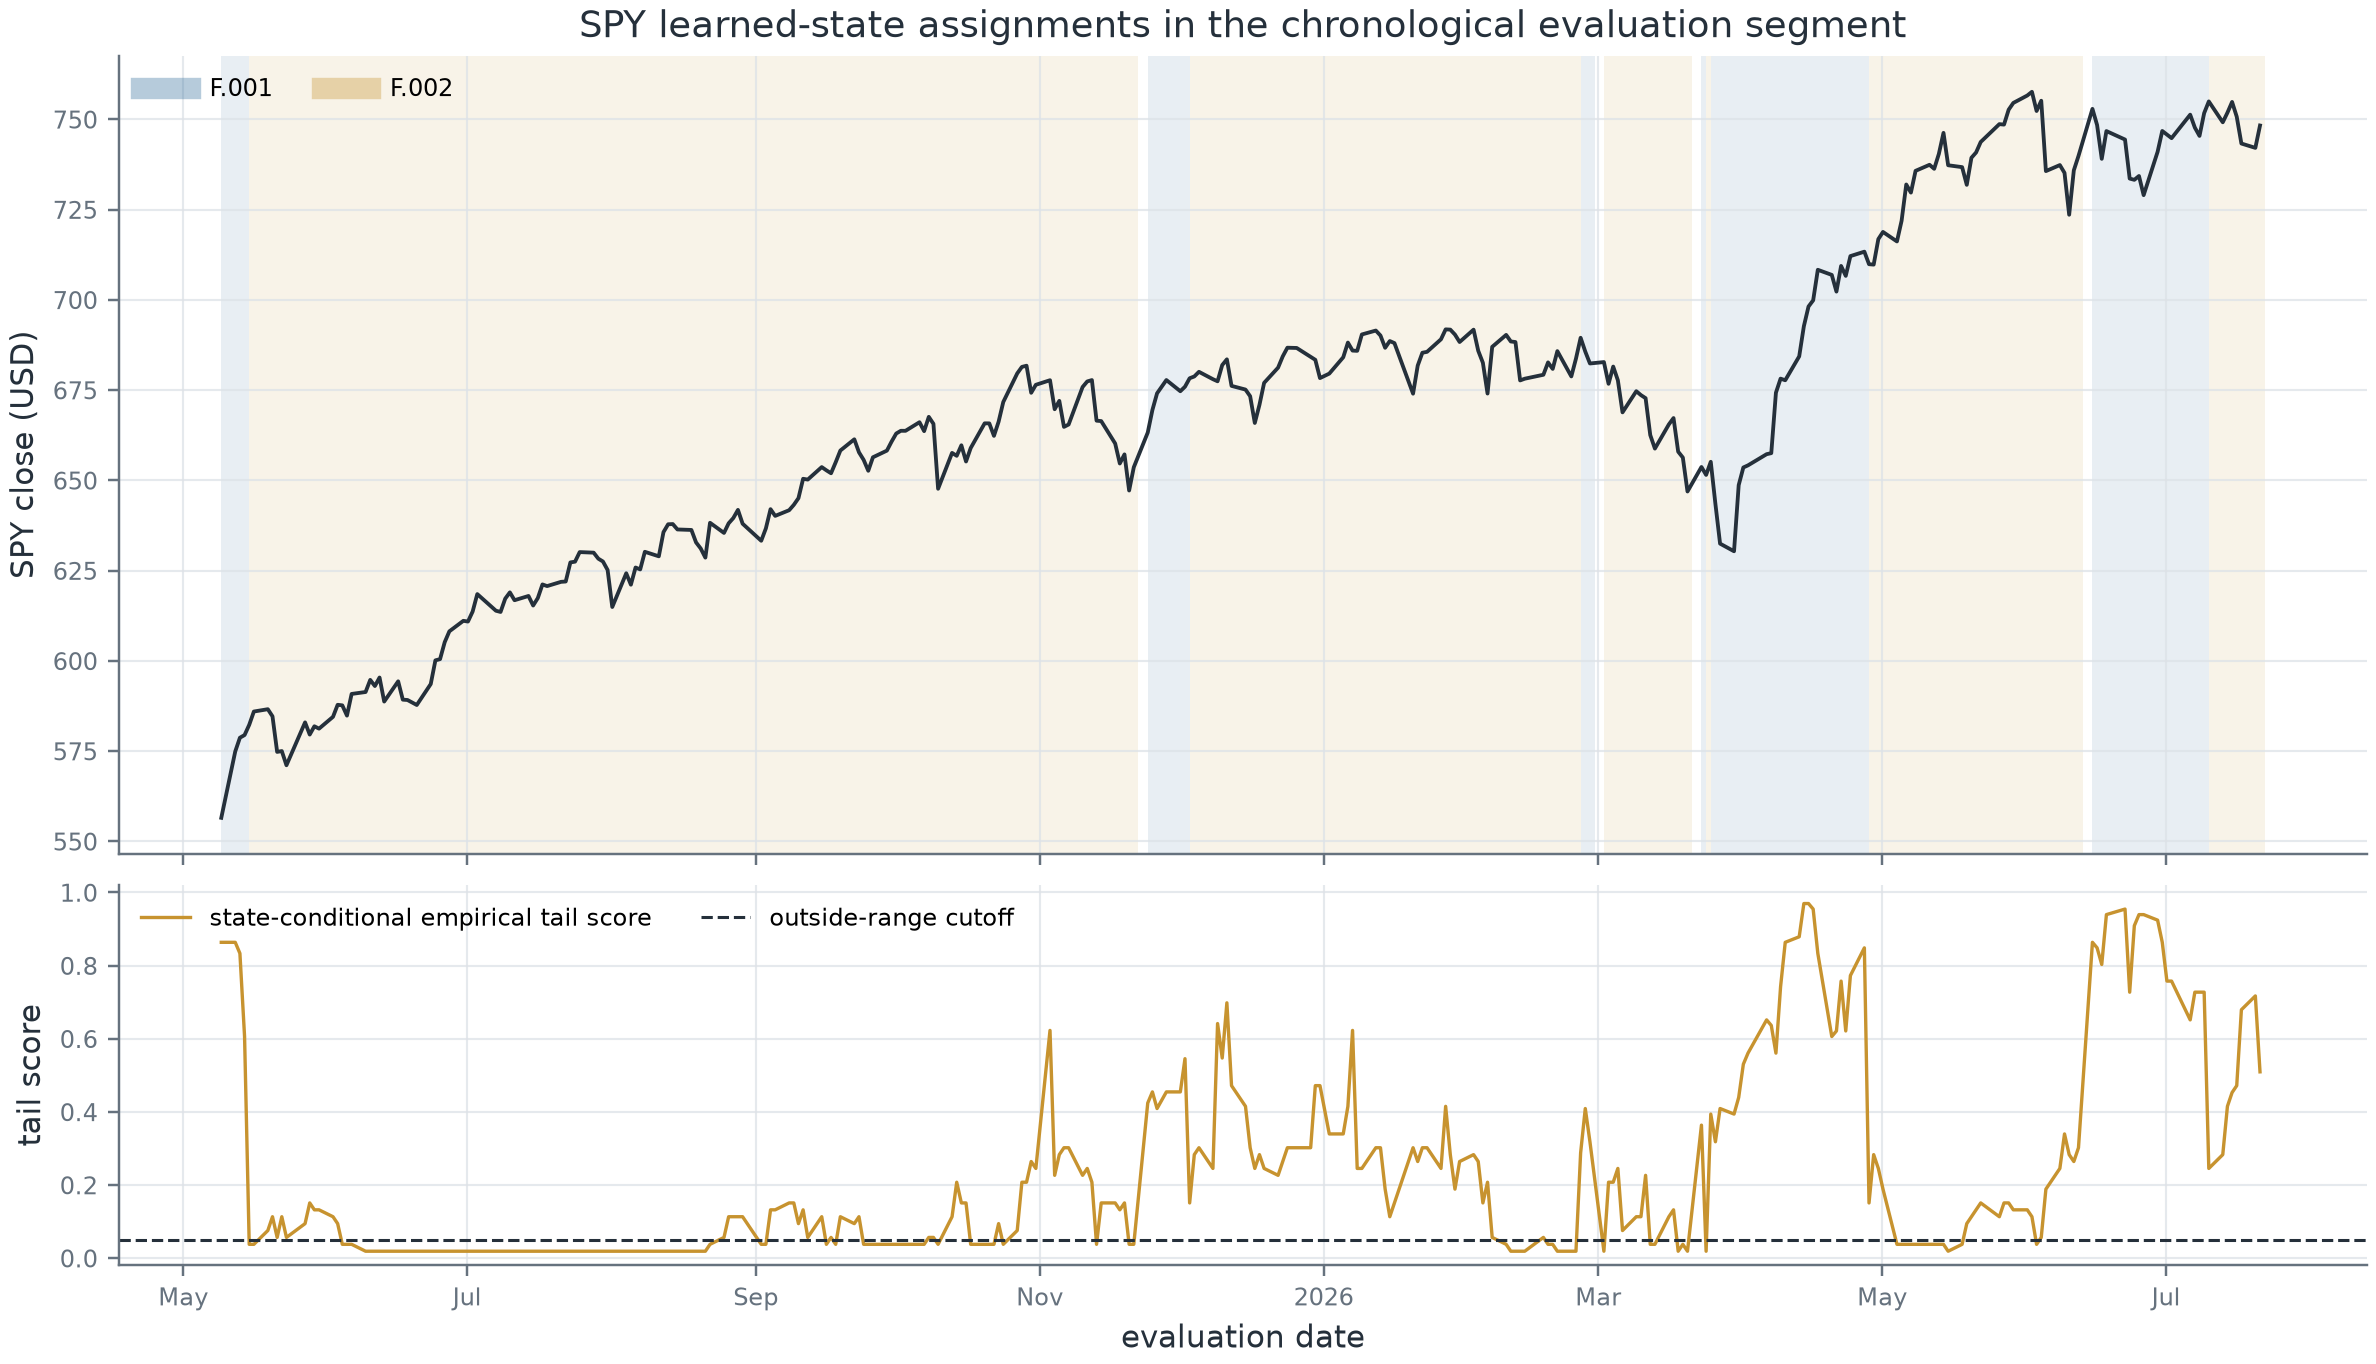

In [6]:
lexicon = pd.read_csv(HERE / "results" / "lexicon_diagnostics.csv")
stability = pd.read_csv(HERE / "results" / "lexicon_window_stability.csv")
display(lexicon)
display(stability)
display(Image(filename=str(HERE / "figures" / "fig_spy_state_timeline.png")))

In [7]:
shadow = json.loads((HERE / "results" / "shadow_boundary.json").read_text(encoding="utf-8"))
live = json.loads((HERE / "results" / "live_endpoint_probe.json").read_text(encoding="utf-8"))
display(pd.DataFrame([shadow]))
display(pd.DataFrame([live["summary"]]))

,alignment_sign_flip_holds,as_of_bar,automated_execution_enabled,call_aligned_pressure,call_path_state,completed_bars,completed_bars_only,excluded_incomplete_bars,incomplete_session_has_zero_field_influence,mode,model_version,performance_claim_evaluated,put_aligned_pressure,put_path_state,rank_influence,retrospective_sections_excluded,schema_version,synthetic_incomplete_session_appended
0,True,2026-07-21,False,0.0255,fading,365,True,1,True,shadow_only,market_field_calculus_v1,False,-0.0255,contradictory,0.0,True,option_market_field_v1,True


,median_elapsed_ms,possible_incomplete_latest_bars,successful_timeframes,timeframes
0,6409.8,9,9,9


## Takeaways

1. **Tested causal behavior and determinism are strong.** Fixed frozen inputs yielded exact prefix agreement and exact repeated hashes in every audit performed.
2. **The representation is not grid-invariant.** Pressure is comparatively stable, but geometry, propagation, scaling, and cascade-related measurements move enough that horizon resolution must be frozen and reported.
3. **Cross-timeframe rendering is feasible, but adjacent bars are not independent evidence.** Every evaluated feature was finite, while pressure lag-one autocorrelation exceeded 0.995 on every SPY timeframe.
4. **The dictionary is currently descriptive.** It is sparse, window-native, sometimes poorly covered, and its nominal 0.05 distance cutoff is not uniformly calibrated forward in time.
5. **Options use must remain shadow-only.** The wrapper passed its completed-bar, sign-alignment, no-retrospective-state, no-ranking-influence, and no-automation checks. No option performance was tested.
6. **Live and paper modes differ.** The deployed endpoint worked on all timeframes but exposed possibly forming latest bars; reproducible experiments should continue to use frozen completed bars and explicit `as_of` timestamps.

See `PRELIMINARY_EVALUATION.md` for exact claim boundaries and the proposed walk-forward performance protocol.